# Dynamic Facial Expression Recognition with Images

In [1]:
name_of_this_notebook = 'efficientnetv2_lstm.ipynb'

In [2]:
!echo "${PYTHONUNBUFFERED}"
!echo "${TF_CPP_MIN_LOG_LEVEL}"
!echo "${TF_FORCE_GPU_ALLOW_GROWTH}"
!echo "${TF_GPU_ALLOCATOR}"

1
2
true
cuda_malloc_async


In [3]:
import re
import ipykernel.iostream

TF_LOG_FILTER_PATTERNS = [
    r'ptx\d+.*is not a recognized feature for this target',
    r'is not a recognized feature for this target \(ignoring feature\)',
    r'\(ignoring feature\)',
    r'successful NUMA node read from SysFS had negative value \(-1\)',
    r'gpu_timer\.cc:114\] Skipping the delay kernel, measurement accuracy will be reduced',
]

KERAS_PROGRESS_PATTERNS = [
    r'ms/step',
    r's/step',
    r'ETA:',
    r'\d+/\d+ \[',   # 12/64 [===>...]
]

_original_write = ipykernel.iostream.OutStream.write

def _filtered_write(self, msg, *args, **kwargs):
    text = str(msg)

    if any(re.search(p, text) for p in KERAS_PROGRESS_PATTERNS):
        _original_write(self, text, *args, **kwargs)
        return

    buf = getattr(self, '_tf_log_filter_buf', '')
    buf += text

    if '\n' not in buf:
        setattr(self, '_tf_log_filter_buf', buf)
        return

    lines = buf.splitlines(keepends=True)
    if not buf.endswith('\n'):
        incomplete = lines.pop()
    else:
        incomplete = ''

    for line in lines:
        if any(re.search(p, line) for p in TF_LOG_FILTER_PATTERNS):
            continue
        _original_write(self, line, *args, **kwargs)

    setattr(self, '_tf_log_filter_buf', incomplete)

ipykernel.iostream.OutStream.write = _filtered_write

print('Notebook log filter installed (targeted, keeps Keras steps).')

Notebook log filter installed (targeted, keeps Keras steps).


In [4]:
import keras

keras.mixed_precision.set_global_policy('mixed_float16')

2025-11-05 23:11:34.780534: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-05 23:11:34.789177: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-05 23:11:34.791996: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
# Ensure Determinism
import random
import numpy as np
import tensorflow as tf

SEED = 13
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)
# tf.config.experimental.enable_op_determinism()

In [6]:
# Ensure GPU works as expected
import json

print('TensorFlow Version:', tf.__version__, ';', 'Keras Version:', keras.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'Number of GPUs detected: {len(gpus)}')
    for gpu in gpus:
        device_details = tf.config.experimental.get_device_details(gpu)
        print(f'Physical Device: {gpu.name}')
        print(f'Name: {device_details["device_name"]}')
        print(f'Compute Capability: {device_details["compute_capability"]}')
else:
    print('No GPUs were detected.')

print(json.dumps(tf.sysconfig.get_build_info(), indent=2))

TensorFlow Version: 2.17.0 ; Keras Version: 3.12.0
Number of GPUs detected: 1
Physical Device: /physical_device:GPU:0
Name: NVIDIA GeForce RTX 5090
Compute Capability: (12, 0)
{
  "cpu_compiler": "/opt/rh/gcc-toolset-11/root/usr/bin/gcc",
  "cuda_compute_capabilities": [
    "sm_100",
    "sm_120",
    "sm_75",
    "sm_80",
    "sm_86",
    "compute_90"
  ],
  "cuda_version": "12.8",
  "cudnn_version": "9",
  "is_cuda_build": true,
  "is_rocm_build": false,
  "is_tensorrt_build": true
}


In [7]:
SEQUENCE_LENGTH = 30
IMAGE_SIZE = (224, 224, 3)
BATCH_SIZE = 32
LR = 1e-3

experiment_name = f'{name_of_this_notebook[:-6]}-b-{BATCH_SIZE}-lr-{LR:.0e}-seed-{SEED}'

## Prepare Data

In [8]:
from pathlib import Path

# data_path = Path(r'/home/thor/Desktop/datasets/2025-11-emoji-hero-dfer/emoji-hero-vr-db-di')
data_path = Path(r'/workspace/datasets/emoji-hero-vr-db-di')
training_set_path = data_path / 'training_set'
validation_set_path = data_path / 'validation_set'
test_set_path = data_path / 'test_set'


In [9]:
emotion_to_id = {
    'Anger': 0,
    'Disgust': 1,
    'Fear': 2,
    'Happiness': 3,
    'Neutral': 4,
    'Sadness': 5,
    'Surprise': 6,
}

### Prepare Class Frequencies and Weights for Loss Function 

In [10]:
from collections import defaultdict


def compute_class_frequencies(data_path: Path) -> dict:
    class_frequencies = {}
    images_per_class = defaultdict(int)

    for class_dir in sorted(data_path.iterdir()):
        num_sequences = 0

        for sequence_dir in class_dir.iterdir():
            num_sequences += 1
            num_files = sum(1 for _ in sequence_dir.iterdir())
            images_per_class[class_dir.name] = images_per_class[class_dir.name] + num_files

        class_id = emotion_to_id[class_dir.name]
        class_frequencies[class_id] = num_sequences

        print(
            f'{class_id} - {class_dir.name:<9} : {images_per_class[class_dir.name]:>8} images {num_sequences:>8} sequences'
        )

    return class_frequencies


In [11]:
print('---TRAINING SET---')
class_frequencies = compute_class_frequencies(training_set_path)

---TRAINING SET---
0 - Anger     :     4500 images      150 sequences
1 - Disgust   :     6360 images      212 sequences
2 - Fear      :     6600 images      220 sequences
3 - Happiness :    12000 images      400 sequences
4 - Neutral   :    12420 images      414 sequences
5 - Sadness   :     8220 images      274 sequences
6 - Surprise  :    10800 images      360 sequences


In [12]:
print('---VALIDATION SET---')
compute_class_frequencies(validation_set_path)

---VALIDATION SET---
0 - Anger     :     3300 images      110 sequences
1 - Disgust   :     3300 images      110 sequences
2 - Fear      :     3300 images      110 sequences
3 - Happiness :     3300 images      110 sequences
4 - Neutral   :     3300 images      110 sequences
5 - Sadness   :     3300 images      110 sequences
6 - Surprise  :     3300 images      110 sequences


{0: 110, 1: 110, 2: 110, 3: 110, 4: 110, 5: 110, 6: 110}

In [13]:
print('---TEST SET---')
compute_class_frequencies(test_set_path)

---TEST SET---
0 - Anger     :     3240 images      108 sequences
1 - Disgust   :     3240 images      108 sequences
2 - Fear      :     3240 images      108 sequences
3 - Happiness :     3240 images      108 sequences
4 - Neutral   :     3240 images      108 sequences
5 - Sadness   :     3240 images      108 sequences
6 - Surprise  :     3240 images      108 sequences


{0: 108, 1: 108, 2: 108, 3: 108, 4: 108, 5: 108, 6: 108}

In [14]:
total_num_samples = sum(class_frequencies.values())
print(f'Found {total_num_samples} samples in the training set.')

class_weights = {
    cls: (total_num_samples / (len(class_frequencies) * freq))
    for cls, freq in class_frequencies.items()
}

print(class_weights)

Found 2030 samples in the training set.
{0: 1.9333333333333333, 1: 1.3679245283018868, 2: 1.3181818181818181, 3: 0.725, 4: 0.7004830917874396, 5: 1.0583941605839415, 6: 0.8055555555555556}


### Prepare Datasets

In [15]:
def load_image_paths_and_labels(dataset_path: Path) -> tuple[list, list]:
    print(f'\nLoading images from {dataset_path}...')
    sequences = []
    labels = []

    for class_dir in sorted(dataset_path.iterdir()):
        label = int(emotion_to_id[class_dir.name])

        for sequence_dir in sorted(class_dir.iterdir()):
            image_paths = [str(img_path) for img_path in sorted(sequence_dir.iterdir())]
            sequences.append(image_paths)
            labels.append(label)

    return sequences, labels


def parse_image(filename: str) -> tf.Tensor:
    image_string_tensor = tf.io.read_file(filename)
    image_int_tensor = tf.io.decode_jpeg(image_string_tensor, channels=IMAGE_SIZE[2])
    return image_int_tensor


def load_sequence(images_paths: tf.Tensor) -> tf.Tensor:
    images = tf.map_fn(parse_image, images_paths, fn_output_signature=tf.uint8)
    images = tf.ensure_shape(images, [SEQUENCE_LENGTH, *IMAGE_SIZE])
    return images


def create_dataset(dataset_path: Path, batch_size: int, training: bool) -> tf.data.Dataset:
    image_paths, labels = load_image_paths_and_labels(dataset_path)
    print('Found ', len(image_paths), ' image sequences and ', len(labels), 'labels.')
    print('Found ', len(image_paths[0]), 'images per sequence.')
    image_paths = tf.constant(image_paths, dtype=tf.string)
    labels = tf.constant(labels, dtype=tf.int32)

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        dataset = dataset.shuffle(len(labels), seed=SEED, reshuffle_each_iteration=True)

    dataset = dataset.map(
        lambda image_paths, labels: (load_sequence(image_paths), labels), num_parallel_calls=tf.data.AUTOTUNE
    )

    # dataset = dataset.batch(batch_size, drop_remainder=training)
    # dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


In [16]:
print('---CREATE TRAINING SET---')
unbatched_training_dataset = create_dataset(training_set_path, BATCH_SIZE, training=True)

---CREATE TRAINING SET---

Loading images from /workspace/datasets/emoji-hero-vr-db-di/training_set...
Found  2030  image sequences and  2030 labels.
Found  30 images per sequence.


In [17]:
# # Ensure correct dataset structure
# paths0, y0 = next(iter(training_dataset.unbatch().take(1).map(lambda x, y: (x, y))))
# print('First Sample/Sequence: ', paths0)
# print('First Label: ', y0)

In [18]:
print('---CREATE VALIDATION SET---')
unbatched_validation_dataset = create_dataset(validation_set_path, BATCH_SIZE, training=False)

---CREATE VALIDATION SET---

Loading images from /workspace/datasets/emoji-hero-vr-db-di/validation_set...
Found  770  image sequences and  770 labels.
Found  30 images per sequence.


## Define Network Architecture

### Data Augmentation Layers

In [19]:
from keras import layers
from keras.saving import register_keras_serializable

@register_keras_serializable(package="seqaug")
class SequenceAugment(layers.Layer):
    """
    Efficient, sequence-consistent video augmentation for inputs shaped (B, T, H, W, C).
    Compatible with Keras 3.12.0 / TF 2.17.0.

    Key design choices:
    - Works in float32 [0..255] space (EfficientNetV2 handles rescaling internally).
    - Applies exactly ONE tf.map_fn over sequences (B dimension). Inside, all ops are vectorized over T frames.
    - Random parameters are sampled ONCE per sequence so all frames get the same transform (no artificial motion).
    - Positive rotation angles are COUNTER-CLOCKWISE (CCW) visually.

    Inference gating:
      Augmentations apply only when `training is True`. Evaluation/predict paths pass inputs through (casted to float32).
    """

    def __init__(
        self,
        image_size=(224, 224),         # Target (H, W) after spatial augs
        crop_scale=(0.90, 1.0),        # RandomResizedCrop: sampled scale ∈ [min,max] of original size
        rotation_max_deg=30.0,         # Uniform |angle| ∈ [0,max], random sign; positive = CCW
        fill_mode="CONSTANT",          # Rotation fill: "CONSTANT", "REFLECT", or "WRAP"
        fill_value=1.0,                # Used when fill_mode == "CONSTANT"
        flip_prob=0.5,                 # Probability to flip the whole sequence horizontally
        brightness_max_delta=20.0,     # Additive brightness jitter in 0..255 domain (sequence-consistent)
        contrast_lower=0.9, contrast_upper=1.1,  # Contrast factor range (sequence-consistent)
        gamma_range=None,              # Optional gamma jitter e.g. (0.95, 1.05); None disables
        clip_after_color=True,         # Clip to [0,255] after color ops to avoid blowouts
        noise_std=0,                   # Gaussian noise std in 0..255 domain (0 disables)
        temporal_shift_max=2,          # Roll by [-k,+k] frames
        frame_drop_prob=0.10,          # Per-frame prob to replace with previous frame
        time_mask_prob=0.10,           # Prob to mask a contiguous temporal block
        time_mask_max_frac=0.20,       # Max fraction of T for temporal block mask
        invert_prob=0.00,              # Prob to invert whole sequence (x -> 255-x).
        solarize_prob=0.05,            # Prob to solarize (> threshold).
        solarize_threshold=(120.0, 160.0),  # Threshold uniform range used when solarizing
        **kwargs
    ):
        super().__init__(**kwargs)
        self.image_size = tuple(image_size)
        self.crop_scale = tuple(crop_scale)
        self.rotation_max_deg = float(rotation_max_deg)
        self.fill_mode = str(fill_mode).upper()
        self.fill_value = float(fill_value)
        self.flip_prob = float(flip_prob)
        self.brightness_max_delta = float(brightness_max_delta)
        self.contrast_lower = float(contrast_lower)
        self.contrast_upper = float(contrast_upper)
        self.gamma_range = None if gamma_range is None else tuple(gamma_range)
        self.clip_after_color = bool(clip_after_color)
        self.noise_std = float(noise_std)
        self.temporal_shift_max = int(temporal_shift_max)
        self.frame_drop_prob = float(frame_drop_prob)
        self.time_mask_prob = float(time_mask_prob)
        self.time_mask_max_frac = float(time_mask_max_frac)
        self.invert_prob = float(invert_prob)
        self.solarize_prob = float(solarize_prob)
        self.solarize_threshold = tuple(solarize_threshold)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "image_size": self.image_size,
            "crop_scale": self.crop_scale,
            "rotation_max_deg": self.rotation_max_deg,
            "fill_mode": self.fill_mode,
            "fill_value": self.fill_value,
            "flip_prob": self.flip_prob,
            "brightness_max_delta": self.brightness_max_delta,
            "contrast_lower": self.contrast_lower,
            "contrast_upper": self.contrast_upper,
            "gamma_range": self.gamma_range,
            "clip_after_color": self.clip_after_color,
            "noise_std": self.noise_std,
            "temporal_shift_max": self.temporal_shift_max,
            "frame_drop_prob": self.frame_drop_prob,
            "time_mask_prob": self.time_mask_prob,
            "time_mask_max_frac": self.time_mask_max_frac,
            "invert_prob": self.invert_prob,
            "solarize_prob": self.solarize_prob,
            "solarize_threshold": self.solarize_threshold,
        })
        return cfg

    # ---------------------------------------------------------------------
    # Spatial / photometric (sequence-consistent across T frames)
    # ---------------------------------------------------------------------

    def _random_resized_crop_sequence(self, seq):
        """
        RandomResizedCrop for the entire sequence (same crop on all frames).
        Usage:
          - Keeps face alignment stable; avoids artificial motion from per-frame crops.
          - For tightly cropped face inputs, prefer scale in ~[0.95, 1.0].
        Input:
          seq: float32 (T, H, W, C) in [0..255]
        Output:
          cropped-resized seq: float32 (T, image_size[0], image_size[1], C)
        """
        t, h, w, c = tf.unstack(tf.shape(seq))
        s = tf.random.uniform([], self.crop_scale[0], self.crop_scale[1])
        nh = tf.maximum(1, tf.cast(s * tf.cast(h, tf.float32), tf.int32))
        nw = tf.maximum(1, tf.cast(s * tf.cast(w, tf.float32), tf.int32))

        # Top-left corner for ALL frames in the sequence
        my = tf.maximum(1, h - nh + 1)
        mx = tf.maximum(1, w - nw + 1)
        y0 = tf.random.uniform([], 0, my, dtype=tf.int32)
        x0 = tf.random.uniform([], 0, mx, dtype=tf.int32)

        # Normalized boxes for tf.image.crop_and_resize
        h_f = tf.cast(h, tf.float32); w_f = tf.cast(w, tf.float32)
        y1 = tf.cast(y0, tf.float32) / h_f
        x1 = tf.cast(x0, tf.float32) / w_f
        y2 = tf.cast(y0 + nh, tf.float32) / h_f
        x2 = tf.cast(x0 + nw, tf.float32) / w_f
        box = tf.stack([y1, x1, y2, x2], axis=0)              # (4,)
        boxes = tf.repeat(tf.expand_dims(box, 0), t, axis=0)  # (T,4)
        idx = tf.range(t, dtype=tf.int32)                     # (T,)

        # Single kernel applying identical crop to each frame
        cropped = tf.image.crop_and_resize(
            seq, boxes=boxes, box_indices=idx,
            crop_size=self.image_size, method="bilinear"
        )
        return cropped

    def _random_rotate_sequence(self, seq):
        """
        Random rotation with a single angle for the whole sequence.
        Usage:
          - Angle magnitude sampled uniformly from [0, rotation_max_deg], sign random (±).
          - Positive angles rotate CCW visually. We use inverse mapping for output->input transform.
          - Choose mild ranges (e.g., 5–8 degrees) for faces to preserve landmarks.
        Input:
          seq: float32 (T, H, W, C)
        Output:
          rotated seq: float32 (T, H, W, C)
        """
        if self.rotation_max_deg <= 0.0:
            return seq

        PI = tf.constant(np.pi, dtype=tf.float32)
        mag = tf.random.uniform([], 0.0, self.rotation_max_deg)   # [0,max]
        sgn = tf.where(tf.random.uniform([]) < 0.5, -1.0, 1.0)    # choose direction
        ang = (mag * sgn) * (PI / 180.0)

        h = tf.cast(self.image_size[0], tf.float32)
        w = tf.cast(self.image_size[1], tf.float32)
        cx = (w - 1.0) * 0.5
        cy = (h - 1.0) * 0.5
        ca = tf.math.cos(ang)
        sa = tf.math.sin(ang)

        # Output->input transform for inverse rotation (-ang)
        a0 = ca; a1 =  sa
        a3 = -sa; a4 = ca
        a2 = cx - a0 * cx - a1 * cy
        a5 = cy - a3 * cx - a4 * cy

        transform = tf.stack([a0, a1, a2, a3, a4, a5, 0.0, 0.0], axis=0)  # (8,)
        t = tf.shape(seq)[0]
        transforms = tf.repeat(tf.expand_dims(transform, 0), t, axis=0)   # (T,8)

        return tf.raw_ops.ImageProjectiveTransformV3(
            images=seq,
            transforms=transforms,
            output_shape=[self.image_size[0], self.image_size[1]],
            interpolation="BILINEAR",
            fill_mode=self.fill_mode,
            fill_value=self.fill_value,
        )

    def _maybe_hflip(self, seq):
        """
        Horizontal flip applied to all frames with probability `flip_prob`.
        Usage:
          - Keep labels correct (multiclass emotion is typically flip-safe).
          - For asymmetrical cues (e.g., text) consider disabling or lower prob.
        """
        cond = tf.less(tf.random.uniform([]), self.flip_prob)
        return tf.cond(cond, lambda: tf.image.flip_left_right(seq), lambda: seq)

    def _color_jitter(self, seq):
        """
        Sequence-consistent color jitter:
          1) Brightness: add a single delta to all frames.
          2) Contrast: scale deviations from mean by one factor.
          3) Optional gamma: tone-curve adjustment in 0..255 space.
        Usage:
          - Keep deltas modest on face data to avoid unnatural skin tones.
          - Set `clip_after_color=True` to clamp to [0,255] and avoid blown highlights.
        """
        if self.brightness_max_delta > 0:
            delta = tf.random.uniform([], -self.brightness_max_delta, self.brightness_max_delta)
            seq = tf.image.adjust_brightness(seq, delta)

        cf = tf.random.uniform([], self.contrast_lower, self.contrast_upper)
        seq = tf.image.adjust_contrast(seq, cf)

        if self.gamma_range is not None:
            g = tf.random.uniform([], self.gamma_range[0], self.gamma_range[1])
            x01 = tf.clip_by_value(seq / 255.0, 0.0, 1.0)
            seq = tf.pow(x01, g) * 255.0

        if self.clip_after_color:
            seq = tf.clip_by_value(seq, 0.0, 255.0)

        return seq

    def _maybe_solarize(self, seq):
        """
        Random solarization: with probability `solarize_prob`, invert pixels above a random threshold.
        Usage:
          - Strong style augment; use sparingly (e.g., 0.02–0.08).
          - Helps encourage shape/edge reliance; may hurt if overused on small datasets.
        """
        if self.solarize_prob <= 0.0:
            return seq
        thr = tf.random.uniform([], self.solarize_threshold[0], self.solarize_threshold[1])
        def apply():
            return tf.where(seq > thr, 255.0 - seq, seq)
        cond = tf.less(tf.random.uniform([]), self.solarize_prob)
        return tf.cond(cond, apply, lambda: seq)

    def _maybe_invert(self, seq):
        """
        Full inversion: with probability `invert_prob`, apply x -> 255 - x to all frames.
        Usage:
          - Another strong style augment; try 0.02–0.05 to start.
          - Great for highlighting contours.
        """
        if self.invert_prob <= 0.0:
            return seq
        cond = tf.less(tf.random.uniform([]), self.invert_prob)
        return tf.cond(cond, lambda: 255.0 - seq, lambda: seq)

    def _gaussian_noise(self, seq):
        """
        Additive per-pixel Gaussian noise with std `noise_std` in the 0..255 domain.
        Usage:
          - Small values (e.g., 2.0–5.0) can improve robustness; keep modest for face data.
        """
        if self.noise_std > 0:
            seq = seq + tf.random.normal(tf.shape(seq), stddev=self.noise_std, dtype=tf.float32)
        return seq

    # ---------------------------------------------------------------------
    # Temporal (length-preserving) — operates along T dimension
    # ---------------------------------------------------------------------

    def _temporal_ops(self, seq):
        """
        Lightweight temporal augmentation bundle:
          - Temporal shift: roll by k ∈ [-temporal_shift_max, +temporal_shift_max].
          - Frame dropout: randomly replace frames with their previous frame.
          - Temporal mask: replace a contiguous time block with the per-sequence mean frame.
        Usage:
          - Keep values mild (shift_max=1, frame_drop_prob ≤ 0.1, time_mask_prob ≤ 0.1).
          - Does not change sequence length; safe for LSTM/TCN backends.
        """
        # shift (simulate minor timing misalignment)
        if self.temporal_shift_max > 0:
            k = tf.random.uniform([], -self.temporal_shift_max, self.temporal_shift_max + 1, dtype=tf.int32)
            seq = tf.roll(seq, shift=k, axis=0)

        # frame dropout (simulate missed frames)
        if self.frame_drop_prob > 0:
            t = tf.shape(seq)[0]
            m = tf.less(tf.random.uniform([t]), self.frame_drop_prob)  # (T,)
            m = tf.reshape(m, [t, 1, 1, 1])
            prev = tf.concat([seq[0:1], seq[:-1]], axis=0)
            seq = tf.where(m, prev, seq)

        # temporal mask (block replacement)
        def apply_mask():
            t = tf.shape(seq)[0]
            maxL = tf.maximum(1, tf.cast(self.time_mask_max_frac * tf.cast(t, tf.float32), tf.int32))
            L = tf.random.uniform([], 1, maxL + 1, dtype=tf.int32)
            s = tf.random.uniform([], 0, t - L + 1, dtype=tf.int32)
            mean = tf.reduce_mean(seq, axis=0, keepdims=True)  # (1,H,W,C)
            return tf.concat([seq[:s], tf.repeat(mean, L, axis=0), seq[s+L:]], axis=0)

        cond = tf.less(tf.random.uniform([]), self.time_mask_prob)
        seq = tf.cond(cond, apply_mask, lambda: seq)
        return seq

    # ---------------------------------------------------------------------
    # Main call: one map over sequences, vectorized ops inside
    # ---------------------------------------------------------------------

    def call(self, x, training=None):
        """
        Forward pass.
        - If `training is True`: apply augmentations.
        - Else (training is False/None): return input cast to float32 (no aug).
        Inputs:
          x: uint8/float32 tensor (B, T, H, W, C)
        Returns:
          float32 tensor (B, T, H, W, C) in [~0..~255]
        """
        if training is not True:
            return tf.cast(x, tf.float32)

        x_f32 = tf.cast(x, tf.float32)

        def _per_sequence(seq):
            # Spatial/photometric (sequence-consistent)
            seq = self._random_resized_crop_sequence(seq)
            seq = self._random_rotate_sequence(seq)
            seq = self._maybe_hflip(seq)
            seq = self._color_jitter(seq)
            seq = self._maybe_solarize(seq)
            seq = self._maybe_invert(seq)
            seq = self._gaussian_noise(seq)
            # Temporal (length-preserving)
            seq = self._temporal_ops(seq)
            return seq

        # Exactly one map over sequences; inside we stay vectorized across frames
        return tf.map_fn(_per_sequence, x_f32, fn_output_signature=tf.float32)


### Build Model

In [20]:
from keras.applications import EfficientNetV2B0
from keras.models import Model


def build_model(num_classes: int, sequence_length: int, image_size: tuple[int, int, int]) -> Model:

    augmentation = SequenceAugment(image_size=image_size[:2])
    backbone = EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=image_size, pooling='avg')
    backbone.trainable = False
    
    input_layer = layers.Input(shape=(sequence_length, *image_size), name='video_input')

    x = augmentation(input_layer)
    
    x = layers.TimeDistributed(backbone, name='td_backbone')(x)
    x = layers.SpatialDropout1D(0.15)(x)
    x = layers.LSTM(32, return_sequences=False, dropout=0.1)(x)
    x = layers.Dropout(0.3, name='top_dropout_1')(x)
    
    output_layer = layers.Dense(num_classes, activation='softmax', dtype='float32', name='pred')(x)

    return Model(input_layer, output_layer, name='DynamicEfficientNet')


In [21]:
model = build_model(len(class_frequencies), SEQUENCE_LENGTH, IMAGE_SIZE)
model.summary()

2025-11-05 23:11:43.553306: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Model: "DynamicEfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 30, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequence_augment                │ (None, 30, 224, 224,   │             0 │
│ (SequenceAugment)               │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_backbone (TimeDistributed)   │ (None, 30, 1280)       │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 30, 1280)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout_1 (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,087,607 (23.22 MB)

 Trainable params: 168,295 (657.40 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [22]:
backbone_layer = model.get_layer('td_backbone').layer
num_layers = len(backbone_layer.layers)
for i, layer in enumerate(backbone_layer.layers):
    print((num_layers - i), layer.name, layer.__class__.__name__)

271 input_layer InputLayer
270 rescaling Rescaling
269 normalization Normalization
268 stem_conv Conv2D
267 stem_bn BatchNormalization
266 stem_activation Activation
265 block1a_project_conv Conv2D
264 block1a_project_bn BatchNormalization
263 block1a_project_activation Activation
262 block2a_expand_conv Conv2D
261 block2a_expand_bn BatchNormalization
260 block2a_expand_activation Activation
259 block2a_project_conv Conv2D
258 block2a_project_bn BatchNormalization
257 block2b_expand_conv Conv2D
256 block2b_expand_bn BatchNormalization
255 block2b_expand_activation Activation
254 block2b_project_conv Conv2D
253 block2b_project_bn BatchNormalization
252 block2b_drop Dropout
251 block2b_add Add
250 block3a_expand_conv Conv2D
249 block3a_expand_bn BatchNormalization
248 block3a_expand_activation Activation
247 block3a_project_conv Conv2D
246 block3a_project_bn BatchNormalization
245 block3b_expand_conv Conv2D
244 block3b_expand_bn BatchNormalization
243 block3b_expand_activation Activation

In [23]:
def unfreeze_layers(model:Model, num_layers: int) -> None:
    if num_layers > 0:
        for layer in model.layers[-num_layers:]:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
            else:
                layer.trainable = True

## Train the Network

In [24]:
import gc
from datetime import datetime
from keras.callbacks import CSVLogger, ModelCheckpoint
from keras.models import load_model


timestamp = datetime.now().strftime("%Y%m%d-%H%M")
checkpoint_dir = Path(f'{timestamp}-checkpoint-{experiment_name}')

training_histories = []
epoch_counter = 0
epochs_per_phase = [4, 4, 6, 6, 20]
layers_to_unfreeze_per_phase = [0, 4, 195, 250, 265]
learning_rate_per_phase = [1e-3, 1e-3, 5e-4, 5e-4, 1e-4]
batch_sizes = [BATCH_SIZE, 32, 32, 16, 16]

In [ ]:
for phase, (epochs, layers_to_unfreeze, learning_rate, batch_size) in enumerate(
        zip(epochs_per_phase, layers_to_unfreeze_per_phase, learning_rate_per_phase, batch_sizes)):
    
    print(f'\n---STARTING TRAINING PHASE {phase}')
    print(f'EPOCHS:{epochs} - BATCH_SIZE: {batch_size} - LEARNING_RATE:{learning_rate:.0e} - LAYERS_TO_UNFREEZE:{layers_to_unfreeze}')

    training_dataset = unbatched_training_dataset.batch(batch_size, drop_remainder=True).prefetch(1)
    validation_dataset = unbatched_validation_dataset.batch(batch_size).prefetch(1)

    phase_dir = checkpoint_dir / f'phase_{phase}'
    phase_dir.mkdir(parents=True, exist_ok=True)

    # Define callbacks
    checkpoint_filepath = str(phase_dir / f'best_model_phase_{phase}.keras')
    model_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath,
                                       save_weights_only=False,
                                       monitor='val_loss',
                                       mode='min',
                                       save_best_only=True)

    csv_logger = CSVLogger(str(phase_dir / f'training_log_{phase}.csv'), append=False)

    callbacks = [model_checkpoint, csv_logger]


    # Load the best model of the previous phase
    if phase > 0:
        old_checkpoint_filepath = checkpoint_filepath.replace(f'phase_{phase}', f'phase_{phase - 1}')
        print(f'Loading model from {old_checkpoint_filepath}')
        model = load_model(old_checkpoint_filepath)

    backbone = model.get_layer('td_backbone').layer
    unfreeze_layers(backbone, layers_to_unfreeze)
    
    # Compile model
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"],
                  jit_compile=False)
    model.summary()

    # Fit model
    hist = model.fit(training_dataset,
                     epochs=epoch_counter + epochs,
                     validation_data=validation_dataset,
                     class_weight=class_weights,
                     callbacks=callbacks,
                     initial_epoch=epoch_counter)

    epoch_counter += epochs
    training_histories.append(hist)
    
    # Clean up
    del callbacks, optimizer
    keras.backend.clear_session()
    del model
    del training_dataset, validation_dataset
    gc.collect()



---STARTING TRAINING PHASE 0
EPOCHS:4 - BATCH_SIZE: 32 - LEARNING_RATE:1e-03 - LAYERS_TO_UNFREEZE:0


Model: "DynamicEfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 30, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequence_augment                │ (None, 30, 224, 224,   │             0 │
│ (SequenceAugment)               │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_backbone (TimeDistributed)   │ (None, 30, 1280)       │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 30, 1280)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout_1 (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,087,607 (23.22 MB)

 Trainable params: 168,295 (657.40 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 30, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequence_augment                │ (None, 30, 224, 224,   │             0 │
│ (SequenceAugment)               │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_backbone (TimeDistributed)   │ (None, 30, 1280)       │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 30, 1280)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout_1 (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,087,607 (23.22 MB)

 Trainable params: 5,965,527 (22.76 MB)

 Non-trainable params: 122,080 (476.88 KB)

Epoch 21/40
126/126 ━━━━━━━━━━━━━━━━━━━━ 125s 851ms/step - accuracy: 0.8775 - loss: 0.4338 - val_accuracy: 0.7610 - val_loss: 0.6526
Epoch 22/40
126/126 ━━━━━━━━━━━━━━━━━━━━ 56s 442ms/step - accuracy: 0.8904 - loss: 0.3723 - val_accuracy: 0.7792 - val_loss: 0.6806
Epoch 23/40
 29/126 ━━━━━━━━━━━━━━━━━━━━ 35s 363ms/step - accuracy: 0.8626 - loss: 0.3881

FileNotFoundError: [Errno 2] No such file or directory: '20251105-2311-checkpoint-efficientnetv2_lstm-b-32-lr-1e-03-seed-13/training_history.png'

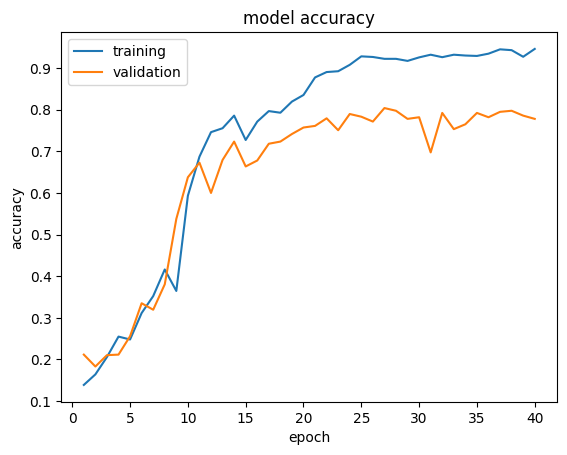

In [41]:
import matplotlib.pyplot as plt


def plot_and_save_combined_history(hists, checkpoint_dir):
    acc = []
    val_acc = []

    for hist in hists:
        acc += hist.history["accuracy"]
        val_acc += hist.history["val_accuracy"]

    epochs = range(1, len(acc) + 1)

    plt.plot(epochs, acc, label="training")
    plt.plot(epochs, val_acc, label="validation")
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(loc="upper left")

    plt.savefig(str(checkpoint_dir / 'training_history.png'))

    plt.show()


plot_and_save_combined_history(training_histories, checkpoint_dir)

In [42]:
import csv


def save_training_history_csv(hists, checkpoint_dir):
    acc = []
    val_acc = []
    val_loss = []
    
    for hist in hists:
        acc.extend(hist.history["accuracy"])
        val_acc.extend(hist.history["val_accuracy"])
        val_loss.extend(hist.history["val_loss"])

    epochs = range(1, len(acc) + 1)

    # CSV-Datei schreiben
    with (checkpoint_dir / 'training_history.csv').open(mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['epoch', 'accuracy', 'val_accuracy', 'val_loss'])
        for epoch, accuracy, val_accuracy, val_loss in zip(epochs, acc, val_acc, val_loss):
            writer.writerow([epoch, f'{accuracy:.4f}', f'{val_accuracy:.4f}', f'{val_loss:.4f}'])


save_training_history_csv(training_histories, checkpoint_dir)

FileNotFoundError: [Errno 2] No such file or directory: '20251105-2311-checkpoint-efficientnetv2_lstm-b-32-lr-1e-03-seed-13/training_history.csv'

In [43]:
final_training_acc = max([max(th.history['accuracy']) for th in training_histories])
print('Final Training Accuracy: ', final_training_acc)

Final Training Accuracy:  0.9459325671195984


## Evaluate Model

In [46]:
#checkpoint_dir = new_checkpoint_dir

'20251105-2311-checkpoint-efficientnetv2_lstm-b-32-lr-1e-03-seed-13'

In [51]:
best_phase = np.argmax([max(th.history["val_accuracy"]) for th in training_histories])
print(f'Best phase was phase {best_phase}.')
best_model = load_model(str(checkpoint_dir / f'phase_{best_phase}' / f'best_model_phase_{best_phase}.keras'))
best_model.trainable = False

Best phase was phase 4.


### Validation Set

In [52]:
validation_dataset = unbatched_validation_dataset.batch(BATCH_SIZE).prefetch(1)

In [53]:
import numpy as np
from sklearn.metrics import classification_report

val_y_pred_vectors = best_model.predict(validation_dataset)
val_y_pred = np.argmax(val_y_pred_vectors, axis=1)
val_y_true = np.concatenate([y for _, y in validation_dataset], axis=0)

val_report = classification_report(val_y_true, val_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(val_report)
val_acc = classification_report(val_y_true, val_y_pred, target_names=emotion_to_id.keys(), digits=4, output_dict=True)['accuracy']

25/25 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step  
              precision    recall  f1-score   support

       Anger     0.7910    0.4818    0.5989       110
     Disgust     0.6667    0.7273    0.6957       110
        Fear     0.7679    0.7818    0.7748       110
   Happiness     0.8898    0.9545    0.9211       110
     Neutral     0.8770    0.9727    0.9224       110
     Sadness     0.7154    0.8000    0.7554       110
    Surprise     0.9259    0.9091    0.9174       110

    accuracy                         0.8039       770
   macro avg     0.8048    0.8039    0.7979       770
weighted avg     0.8048    0.8039    0.7979       770



### Test Set

In [54]:
test_dataset = create_dataset(test_set_path, BATCH_SIZE, training=False).map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(1)


Loading images from /workspace/datasets/emoji-hero-vr-db-di/test_set...
Found  756  image sequences and  756 labels.
Found  30 images per sequence.


In [55]:
test_y_pred_vectors = best_model.predict(test_dataset)
test_y_pred = np.argmax(test_y_pred_vectors, axis=1)
test_y_true = np.concatenate([y for _, y in test_dataset], axis=0)

test_report = classification_report(test_y_true, test_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(test_report)
test_acc = classification_report(test_y_true, test_y_pred, target_names=emotion_to_id.keys(), digits=4,output_dict=True)['accuracy']

24/24 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step  
              precision    recall  f1-score   support

       Anger     0.5495    0.4630    0.5025       108
     Disgust     0.5139    0.6852    0.5873       108
        Fear     0.7320    0.6574    0.6927       108
   Happiness     0.7500    0.9167    0.8250       108
     Neutral     0.8710    0.7500    0.8060       108
     Sadness     0.8462    0.8148    0.8302       108
    Surprise     0.9158    0.8056    0.8571       108

    accuracy                         0.7275       756
   macro avg     0.7397    0.7275    0.7287       756
weighted avg     0.7397    0.7275    0.7287       756



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


def plot_confusion_matrix(y_true, y_pred):
    class_names = emotion_to_id.keys()

    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    fig = plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout()
    plt.show()

    return fig


cm_figure = plot_confusion_matrix(test_y_true, test_y_pred)

In [ ]:
def save_evaluation_results(report, cm_figure, checkpoint_dir):
    with (checkpoint_dir / 'classification_report.txt').open(mode='w') as f:
        f.write(report)
    cm_figure.savefig(str(checkpoint_dir / 'confusion_matrix.png'))


save_evaluation_results(test_report, cm_figure, checkpoint_dir)

In [ ]:
import time

time.sleep(3)

In [ ]:
def add_test_acc_to_checkpoint_dir_name(checkpoint_dir, train_acc, val_acc, test_acc):
    new_name = checkpoint_dir.name + f'_train_{str(train_acc)[2:6]}_val_{str(val_acc)[2:6]}_test_{str(test_acc)[2:6]}'
    new_path = checkpoint_dir.parent / new_name
    checkpoint_dir.rename(new_path)
    return new_path


new_checkpoint_dir = add_test_acc_to_checkpoint_dir_name(checkpoint_dir, final_training_acc, val_acc, test_acc)

In [ ]:
time.sleep(3)

In [ ]:
import shutil

shutil.copy2((Path() / name_of_this_notebook), (new_checkpoint_dir / name_of_this_notebook))

In [ ]:
time.sleep(300)

In [ ]:
# import os, glob
# import tensorflow as tf
# import numpy as np
# import matplotlib.pyplot as plt

# def load_sequence_from_dir(dir_path, image_size=(224,224), max_frames=None):
#     """Load n frames from a directory, sorted by name, decode to uint8, resize to image_size.
#        Returns a (T,H,W,C) uint8 tensor."""
#     paths = sorted(glob.glob(os.path.join(dir_path, "*")))
#     if max_frames is not None:
#         paths = paths[:max_frames]
#     imgs = []
#     for p in paths:
#         raw = tf.io.read_file(p)
#         img = tf.image.decode_image(raw, channels=3, expand_animations=False)  # (H,W,C), uint8
#         img = tf.image.resize(img, image_size, method='bilinear')              # float32
#         img = tf.cast(tf.round(tf.clip_by_value(img, 0.0, 255.0)), tf.uint8)   # back to uint8
#         imgs.append(img)
#     seq = tf.stack(imgs, axis=0)  # (T,H,W,C)
#     return seq

# def preview_sequence(seq, title, save_path=None, ncols=6):
#     """Plot a grid of the first frames of a sequence."""
#     T = seq.shape[0]
#     ncols = min(ncols, T)
#     nrows = int(np.ceil(T / ncols))
#     plt.figure(figsize=(2.5*ncols, 2.5*nrows))
#     for i in range(T):
#         plt.subplot(nrows, ncols, i+1)
#         plt.imshow(np.clip(seq[i].astype(np.uint8), 0, 255))
#         plt.axis("off")
#     plt.suptitle(title)
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=120)
#     plt.show()

# def test_dir_with_random_angle_via_layer(dir_path, image_size=(224,224), n=30, rotation_max_deg=15.0, seed=None):
#     if seed is not None:
#         tf.random.set_seed(seed)
#     seq = load_sequence_from_dir(dir_path, image_size=image_size, max_frames=n)   # (T,H,W,C) uint8
#     batch = tf.expand_dims(seq, axis=0)                                           # (1,T,H,W,C)
#     aug = SequenceAugment()
#     aug_seq = aug(batch, training=True)[0].numpy()                                 # (T,H,W,C) float32
#     preview_sequence(seq.numpy(), f"Original ({n} frames)")
#     preview_sequence(aug_seq, f"Rotated (random ∈ [0,{rotation_max_deg}]°)")


In [ ]:
# for i in range(100):
#     if i < 38:
#         continue
#     if i >= 45:
#         break
#     emotion_dir = next(test_set_path.iterdir())
#     print(emotion_dir)
#     sequence_dir = next(emotion_dir.iterdir())
#     print(sequence_dir)
#     test_dir_with_random_angle_via_layer(str(sequence_dir), rotation_max_deg=30)
